In [1]:
import pandas as pd
import polars as pl
import polars.selectors as cs
import soccerdata as sd
import matplotlib.pyplot as plt
import sklearn as skl
import pandas as ps
import numpy as np
import pyarrow
import seaborn as sb
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, rankdata
from catboost import CatBoostClassifier
from IPython.display import display
import xgboost as xgb

[08/20/26 19:10:37] INFO     No custom team name replacements found. You can configure these in       ]8;id=14228615;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=14228616;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py#92\92]8;;\
                             /home/caff/soccerdata/config/teamname_replacements.json.                              

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=14228622;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=14228623;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py#190\190]8;;\
                             /home/caff/soccerdata/config/league_dict.json.                                        

In [2]:
fbref = sd.FBref(seasons = "2025")

[08/20/26 19:10:38] INFO     Saving cached data to /home/caff/soccerdata/data/FBref                  ]8;id=14228630;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=14228631;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_common.py#250\250]8;;\

In [3]:

"""s = fbref.read_player_season_stats(stat_type="standard")
s1 = pl.from_pandas(s, include_index=True)
progress = fbref.read_player_season_stats(stat_type="possession")
p1 = pl.from_pandas(progress, include_index=True)
passes = fbref.read_player_season_stats(stat_type="passing")
p2 = pl.from_pandas(passes, include_index=True)
creative = fbref.read_player_season_stats(stat_type="goal_shot_creation")
c1 = pl.from_pandas(creative, include_index=True)
defense = fbref.read_player_season_stats(stat_type="defense")
d1 = pl.from_pandas(defense, include_index=True)

S = s1.drop("season")
S = S.drop("('nation', '')")
S = S.drop("('born', '')")
S = S.drop("('age', '')")

S = S.drop([
    "('Playing Time', 'MP')",
    "('Playing Time', 'Starts')",
    "('Playing Time', 'Min')"
])

D = d1.drop("season")
D = D.drop("('nation', '')")
D = D.drop("('born', '')")
D = D.drop("('age', '')")
D = D.drop("('90s', '')")

C = c1.drop("season")
C = C.drop("('nation', '')")
C = C.drop("('born', '')")
C = C.drop("('age', '')")
C = C.drop("('90s', '')")
C = C.drop("('SCA', 'SCA90')")
C = C.drop("('GCA', 'GCA90')")

P = p1.drop("season")
P = P.drop("('nation', '')")
P = P.drop("('born', '')")
P = P.drop("('age', '')")
P = P.drop("('90s', '')")

P2 = p2.drop("season")
P2 = P2.drop("('nation', '')")

P2 = P2.drop("('90s', '')")

all_player = S.join(P, on=["league", "team", "player"], how="inner", suffix="_progress")
all_player = all_player.join(C, on=["league", "team", "player"], how="inner", suffix="_creative")
all_player = all_player.join(D, on=["league", "team", "player"], how="inner", suffix="_defense")
all_player = all_player.join(P2, on=["league", "team", "player"], how="inner", suffix="_passes")
all_player = all_player.drop("('pos', '')_defense")
all_player = all_player.drop("('pos', '')_passes")
all_player = all_player.drop("('pos', '')_creative")
all_player = all_player.drop("('pos', '')_progress")
all_player = all_player.drop(cs.matches(r"^\('Per 90 Minutes'.*"))
all_player = all_player.fill_nan(0.0)
all_player.write_csv("player_stats.csv")
"""

[08/20/26 19:10:42] WARNING  <>:56: SyntaxWarning: invalid escape sequence '\('                     ]8;id=14228638;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=14228639;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py#112\112]8;;\
                                                                                                                   

                    WARNING  <>:56: SyntaxWarning: invalid escape sequence '\('                     ]8;id=14228644;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=14228645;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py#112\112]8;;\
                                                                                                                   

                    WARNING  /tmp/ipykernel_159889/3064003154.py:56: SyntaxWarning: invalid escape  ]8;id=14228650;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=14228651;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py#112\112]8;;\
                             sequence '\('                                                                         
                               all_player = all_player.drop(cs.matches(r"^\('Per 90 Minutes'.*"))                  
                                                                                                                   

's = fbref.read_player_season_stats(stat_type="standard")\ns1 = pl.from_pandas(s, include_index=True)\nprogress = fbref.read_player_season_stats(stat_type="possession")\np1 = pl.from_pandas(progress, include_index=True)\npasses = fbref.read_player_season_stats(stat_type="passing")\np2 = pl.from_pandas(passes, include_index=True)\ncreative = fbref.read_player_season_stats(stat_type="goal_shot_creation")\nc1 = pl.from_pandas(creative, include_index=True)\ndefense = fbref.read_player_season_stats(stat_type="defense")\nd1 = pl.from_pandas(defense, include_index=True)\n\nS = s1.drop("season")\nS = S.drop("(\'nation\', \'\')")\nS = S.drop("(\'born\', \'\')")\nS = S.drop("(\'age\', \'\')")\n\nS = S.drop([\n    "(\'Playing Time\', \'MP\')",\n    "(\'Playing Time\', \'Starts\')",\n    "(\'Playing Time\', \'Min\')"\n])\n\nD = d1.drop("season")\nD = D.drop("(\'nation\', \'\')")\nD = D.drop("(\'born\', \'\')")\nD = D.drop("(\'age\', \'\')")\nD = D.drop("(\'90s\', \'\')")\n\nC = c1.drop("season")\n

In [4]:
all_player = pl.read_csv("player_stats.csv")
all_player

league,team,player,"('pos', '')","('Playing Time', '90s')","('Performance', 'Gls')","('Performance', 'Ast')","('Performance', 'G+A')","('Performance', 'G-PK')","('Performance', 'PK')","('Performance', 'PKatt')","('Performance', 'CrdY')","('Performance', 'CrdR')","('Expected', 'xG')","('Expected', 'npxG')","('Expected', 'xAG')","('Expected', 'npxG+xAG')","('Progression', 'PrgC')","('Progression', 'PrgP')","('Progression', 'PrgR')","('Touches', 'Touches')","('Touches', 'Def Pen')","('Touches', 'Def 3rd')","('Touches', 'Mid 3rd')","('Touches', 'Att 3rd')","('Touches', 'Att Pen')","('Touches', 'Live')","('Take-Ons', 'Att')","('Take-Ons', 'Succ')","('Take-Ons', 'Succ%')","('Take-Ons', 'Tkld')","('Take-Ons', 'Tkld%')","('Carries', 'Carries')","('Carries', 'TotDist')","('Carries', 'PrgDist')","('Carries', 'PrgC')","('Carries', '1/3')",…,"('Tackles', 'Att 3rd')","('Challenges', 'Tkl')","('Challenges', 'Att')","('Challenges', 'Tkl%')","('Challenges', 'Lost')","('Blocks', 'Blocks')","('Blocks', 'Sh')","('Blocks', 'Pass')","('Int', '')","('Tkl+Int', '')","('Clr', '')","('Err', '')","('age', '')","('born', '')","('Total', 'Cmp')","('Total', 'Att')","('Total', 'Cmp%')","('Total', 'TotDist')","('Total', 'PrgDist')","('Short', 'Cmp')","('Short', 'Att')","('Short', 'Cmp%')","('Medium', 'Cmp')","('Medium', 'Att')","('Medium', 'Cmp%')","('Long', 'Cmp')","('Long', 'Att')","('Long', 'Cmp%')","('Ast', '')","('xAG', '')","('Expected', 'xA')","('Expected', 'A-xAG')","('KP', '')","('1/3', '')","('PPA', '')","('CrsPA', '')","('PrgP', '')"
str,str,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,i64,i64,i64,i64,i64,…,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,f64,i64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64
"""ENG-EFL Championship""","""Birmingham City""","""Alex Cochrane""","""DF""",16.3,1,4,5,1,0,0,3,0,0.3,0.3,1.8,2.2,16,100,32,1222,42,368,607,255,3,1222,6,3,50.0,3,50.0,578,2341,1187,16,12,…,4,14,26,53.8,12,7,2,5,19,37,56,0,"""25-242""",2000,776,1075,72.2,13702,5836,344,371,92.7,369,467,79.0,56,202,27.7,4,1.8,1.7,2.2,18,87,9,7,100
"""ENG-EFL Championship""","""Birmingham City""","""Alfons Sampsted""","""DF,MF""",0.3,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,1,1,12,0,2,5,5,1,12,0,0,null,0,null,6,23,17,1,0,…,0,0,0,null,0,0,0,0,0,0,2,0,"""27-257""",1998,6,9,66.7,104,38,2,4,50.0,4,4,100.0,0,1,0.0,0,0.0,0.0,0.0,0,1,0,0,1
"""ENG-EFL Championship""","""Birmingham City""","""Bright Osayi-Samuel""","""DF""",8.7,0,0,0,0,0,0,5,0,0.3,0.3,0.2,0.5,17,17,43,459,17,132,214,118,12,459,16,8,50.0,8,50.0,205,1189,550,17,16,…,0,3,9,33.3,6,4,0,4,11,20,20,0,"""27-353""",1997,295,374,78.9,4555,1173,153,171,89.5,128,158,81.0,9,25,36.0,0,0.2,0.3,-0.2,3,15,4,2,17
"""ENG-EFL Championship""","""Birmingham City""","""Christoph Klarer""","""DF""",21.0,2,0,2,2,0,0,4,0,1.2,1.2,0.7,1.9,20,89,4,1781,217,868,845,79,30,1781,12,7,58.3,4,33.3,1016,5650,3606,20,13,…,1,15,23,65.2,8,11,7,4,29,52,157,0,"""25-188""",2000,1329,1519,87.5,24763,8927,446,477,93.5,785,852,92.1,90,166,54.2,0,0.7,0.7,-0.7,6,76,5,1,89
"""ENG-EFL Championship""","""Birmingham City""","""Demarai Gray""","""FW,MF""",17.5,5,4,9,5,0,0,2,0,3.5,3.5,4.1,7.6,55,33,159,779,18,88,293,411,59,779,53,21,39.6,27,50.9,472,3251,1574,55,38,…,8,16,27,59.3,11,23,1,22,6,30,19,0,"""29-174""",1996,393,550,71.5,6276,1227,215,248,86.7,137,189,72.5,31,76,40.8,4,4.1,3.9,-0.1,21,18,15,5,33
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Por-Primeira Liga""","""Vitória""","""Tomás Händel""","""MF""",3.0,0,1,1,0,0,0,0,0,0.2,0.2,0.3,0.5,4,11,9,136,9,24,78,35,2,136,0,0,null,0,null,72,276,146,4,2,…,0,3,5,60.0,2,2,1,1,5,11,3,1,"""25-023""",2000,89,114,78.1,1403,292,49,59,83.1,31,38,81.6,6,10,60.0,1,0.3,0.3,0.7,2,10,1,0,11
"""Por-Primeira Liga""","""Vitória""","""Toni Borevkovic""","""DF""",1.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,1,0,

In [5]:
all_player = all_player.filter((pl.col("('pos', '')").str.contains("DF")))
#all_player = all_player.filter(pl.col("league").str.contains("ENG-Premier League"))

minutes_col = "('Playing Time', '90s')"
pct_cols = [c for c in all_player.columns if "%" in c]
id_cols = ["league", "team", "player", "('pos', '')", "('age', '')", "('born', '')"]
count_cols = [
    c for c in all_player.select(cs.numeric()).columns
    if c not in pct_cols and c != minutes_col and c not in id_cols
]

all_player = (
    all_player.sort(minutes_col, descending=True)
    .group_by("player", maintain_order=True)
    .agg(
        pl.first("league"),
        pl.first("team"),
        pl.first("('pos', '')"),
        pl.col(minutes_col).sum(),
        *[pl.col(c).sum() for c in count_cols],
        *[
            ((pl.col(c) * pl.col(minutes_col)).sum()
             / pl.col(minutes_col).filter(pl.col(c).is_not_null()).sum()).alias(c)
            for c in pct_cols
        ],
    )
)

# Per-90 stats get noisy on small samples; 3 nineties (~270 min) removes the
# worst of it while keeping rotation players (e.g. Lewis Hall at 4.8 nineties).
min_90s = 3.0
all_player = all_player.filter(pl.col(minutes_col) >= min_90s)
all_player = all_player.drop("('pos', '')")
all_player

player,league,team,"('Playing Time', '90s')","('Performance', 'Gls')","('Performance', 'Ast')","('Performance', 'G+A')","('Performance', 'G-PK')","('Performance', 'PK')","('Performance', 'PKatt')","('Performance', 'CrdY')","('Performance', 'CrdR')","('Expected', 'xG')","('Expected', 'npxG')","('Expected', 'xAG')","('Expected', 'npxG+xAG')","('Progression', 'PrgC')","('Progression', 'PrgP')","('Progression', 'PrgR')","('Touches', 'Touches')","('Touches', 'Def Pen')","('Touches', 'Def 3rd')","('Touches', 'Mid 3rd')","('Touches', 'Att 3rd')","('Touches', 'Att Pen')","('Touches', 'Live')","('Take-Ons', 'Att')","('Take-Ons', 'Succ')","('Take-Ons', 'Tkld')","('Carries', 'Carries')","('Carries', 'TotDist')","('Carries', 'PrgDist')","('Carries', 'PrgC')","('Carries', '1/3')","('Carries', 'CPA')","('Carries', 'Mis')","('Carries', 'Dis')",…,"('Tackles', 'Att 3rd')","('Challenges', 'Tkl')","('Challenges', 'Att')","('Challenges', 'Lost')","('Blocks', 'Blocks')","('Blocks', 'Sh')","('Blocks', 'Pass')","('Int', '')","('Tkl+Int', '')","('Clr', '')","('Err', '')","('Total', 'Cmp')","('Total', 'Att')","('Total', 'TotDist')","('Total', 'PrgDist')","('Short', 'Cmp')","('Short', 'Att')","('Medium', 'Cmp')","('Medium', 'Att')","('Long', 'Cmp')","('Long', 'Att')","('Ast', '')","('xAG', '')","('Expected', 'xA')","('Expected', 'A-xAG')","('KP', '')","('1/3', '')","('PPA', '')","('CrsPA', '')","('PrgP', '')","('Take-Ons', 'Succ%')","('Take-Ons', 'Tkld%')","('Challenges', 'Tkl%')","('Total', 'Cmp%')","('Short', 'Cmp%')","('Medium', 'Cmp%')","('Long', 'Cmp%')"
str,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""Christoph Klarer""","""ENG-EFL Championship""","""Birmingham City""",21.0,2,0,2,2,0,0,4,0,1.2,1.2,0.7,1.9,20,89,4,1781,217,868,845,79,30,1781,12,7,4,1016,5650,3606,20,13,0,9,5,…,1,15,23,8,11,7,4,29,52,157,0,1329,1519,24763,8927,446,477,785,852,90,166,0,0.7,0.7,-0.7,6,76,5,1,89,58.3,33.3,65.2,87.5,93.5,92.1,54.2
"""Matthew Clarke""","""ENG-EFL Championship""","""Derby County""",21.0,1,1,2,1,0,0,3,0,0.8,0.8,0.8,1.7,5,40,6,1302,249,765,437,102,36,1302,5,3,2,459,2204,1036,5,9,0,19,7,…,0,15,26,11,38,24,14,25,63,181,0,709,952,14422,5644,206,236,401,492,92,201,1,0.8,0.6,0.2,7,36,3,1,40,60.0,40.0,57.7,74.5,87.3,81.5,45.8
"""Dara O'Shea""","""ENG-EFL Championship""","""Ipswich Town""",21.0,1,1,2,1,0,0,0,0,1.2,1.2,0.9,2.1,16,67,7,1623,212,855,703,78,40,1623,5,3,2,968,5076,2847,16,4,1,13,2,…,0,3,10,7,20,18,2,15,21,130,2,1169,1399,24487,10012,316,351,697,765,146,249,1,0.9,0.9,0.1,8,95,4,0,67,60.0,40.0,30.0,83.6,90.0,91.1,58.6
"""Jannik Vestergaard""","""ENG-EFL Championship""","""Leicester City""",21.0,2,0,2,2,0,0,4,0,1.5,1.5,0.2,1.7,7,65,2,1559,284,821,680,69,31,1559,7,7,0,845,4409,2527,7,11,0,9,2,…,2,16,23,7,21,13,8,21,52,181,1,1112,1274,19908,9102,450,472,556,607,86,154,0,0.2,0.5,-0.2,2,70,4,0,65,100.0,0.0,69.6,87.3,95.3,91.6,55.8
"""Michał Helik""","""ENG-EFL Championship""","""Oxford United""",21.0,0,2,2,0,0,0,1,0,1.7,1.7,2.3,4.0,4,43,15,1053,180,585,395,80,51,1053,5,2,3,413,1451,771,4,7,0,7,0,…,0,12,19,7,36,27,9,34,62,172,0,551,734,10355,4345,198,230,291,359,53,120,2,2.3,2.2,-0.3,11,27,3,0,43,40.0,60.0,63.2,75.1,86.1,81.1,44.2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Geoffrey Kondogbia""","""FRA-Ligue 1""","""Marseille""",3.0,0,0,0,0,0,0,1,0,0.1,0.1,0.0,0.1,1,13,2,291,17,86,182,25,2,291,5,5,0,189,632,313,1,2,0,2,3,…,1,2,4,2,7,4,3,4,10,9,0,226,253,3354,755,110,119,90,98,9,16,0,0.0,0.1,0.0,0,16,2,0,13,100.0,0.0,50.0,89.3,92.4,91.8,56.3
"""Denis Odoi""","""NED-Eredivisie""","""NAC Breda""",3.0,0,0,0,0,0,0,1,0,0.2,0.2,0.4,0.6,4,18,2,215,18,60,139,17,6,215,1,1,0,110,528,283,4,1,0,4,1,…,1,1,3,2,2,0,2,3,7

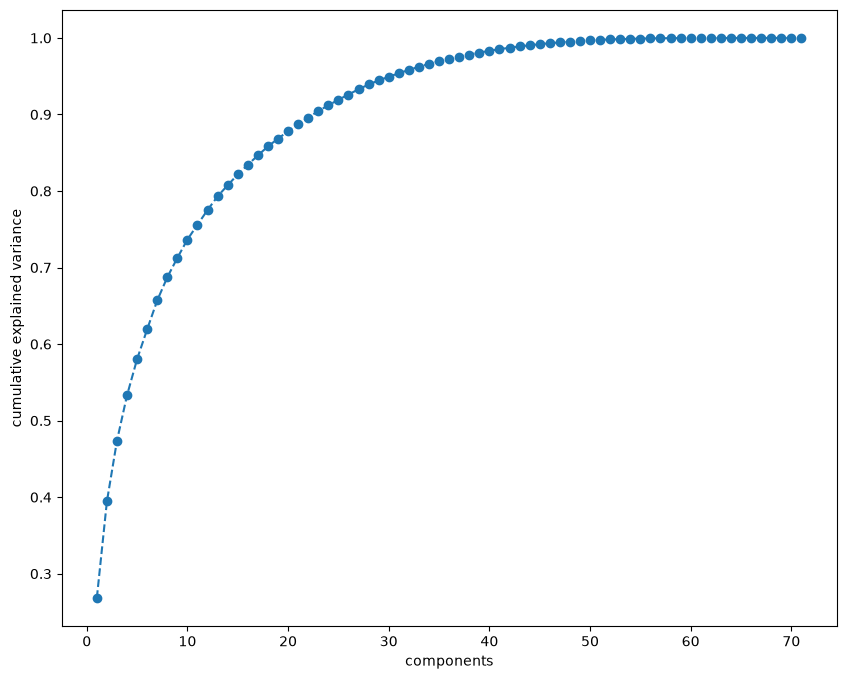

In [6]:
# Drop redundant columns so correlated stat families are not counted twice:
# totals whose components are also present, and columns that FBref repeats
# across the joined tables.
redundant_cols = [
    "('Performance', 'G+A')",     # Gls + Ast
    "('Performance', 'G-PK')",    # Gls - PK
    "('Expected', 'npxG+xAG')",   # npxG + xAG
    "('Expected', 'A-xAG')",      # Ast - xAG
    "('Progression', 'PrgC')",    # duplicate of ('Carries', 'PrgC')
    "('Progression', 'PrgP')",    # duplicate of ('PrgP', '') from passing
    "('Progression', 'PrgR')",    # duplicate of ('Receiving', 'PrgR')
    "('Ast', '')",                # duplicate of ('Performance', 'Ast')
    "('xAG', '')",                # duplicate of ('Expected', 'xAG')
    "('Touches', 'Touches')",     # sum of the zone touches
    "('Touches', 'Live')",        # near-identical to total touches
    "('SCA', 'SCA')",             # sum of the SCA Types columns
    "('GCA', 'GCA')",             # sum of the GCA Types columns
    "('Total', 'Cmp')",           # Short + Medium + Long completions
    "('Total', 'Att')",           # Short + Medium + Long attempts
    "('Tackles', 'Tkl')",         # sum of the zone tackles
    "('Tkl+Int', '')",            # Tkl + Int
    "('Blocks', 'Blocks')",       # Sh + Pass blocks
    "('Challenges', 'Lost')",     # challenge Att - Tkl
]
all_player = all_player.drop([c for c in redundant_cols if c in all_player.columns])

numeric_cols_all = all_player.select(cs.numeric()).columns
pct_cols = [c for c in numeric_cols_all if "%" in c]
cols_to_normalize = [c for c in numeric_cols_all if c not in pct_cols and c != minutes_col]

all_player = all_player.with_columns([
    (pl.col(col_name) / pl.col(minutes_col)).alias(col_name)
    for col_name in cols_to_normalize
])

all_player = all_player.with_columns([
    pl.when(pl.col(c).is_nan()).then(None).otherwise(pl.col(c)).alias(c)
    for c in numeric_cols_all
])
all_player = all_player.with_columns([
    pl.col(c).fill_null(pl.col(c).median()) for c in pct_cols
])
all_player = all_player.with_columns([
    pl.col(c).fill_null(0.0) for c in cols_to_normalize
])

from sklearn.preprocessing import RobustScaler

feature_cols = [c for c in numeric_cols_all if c != minutes_col]
X_filtered = all_player.select(feature_cols).to_numpy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_filtered)

tester = pd.DataFrame(X_scaled, columns=feature_cols)
pca = PCA()
pca.fit(tester)
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel("components")
plt.ylabel("cumulative explained variance")
plt.show()

In [7]:
#結果：23変数くらいが丸い。それ前後は弄ってみても良いかも。
pca = PCA(23)
pca.fit(tester)
pcaed = pca.transform(tester)

In [11]:
target_player = "Luke Shaw"

matches = all_player.with_row_index().filter(
    pl.col("player").str.contains("(?i)" + target_player)
)
if matches.height == 0:
    raise ValueError(
        f"no player matching {target_player!r} — check the spelling, the DF position "
        f"filter, and the >= {min_90s} nineties filter in the cell above"
    )
if matches.height > 1:
    print("multiple matches — using the first:")
    with pl.Config(tbl_rows=-1):
        display(matches.select("player", "team", "league"))
idx = int(matches["index"][0])
print(f"target: {all_player['player'][idx]} ({all_player['team'][idx]}, {all_player['league'][idx]})")

target: Luke Shaw (Manchester Utd, ENG-Premier League)


In [12]:
n_samples, n_features = X_scaled.shape
top_n = 9

def top_table(scores, score_name):
    order = np.argsort(scores)[::-1][:top_n]
    return all_player[order].select("player", "team", "league").with_columns(
        pl.Series(score_name, scores[order])
    )

scores_by_model = {}

delta = 1.0

col_min = X_scaled.min(axis=0)
col_range = X_scaled.max(axis=0) - col_min
shared_max = col_range.max() + delta
X_pos = X_scaled - col_min + (shared_max - col_range)  # positive, common max

# Largest-range features first, then stagger each past the previous maximum.
sid_main = np.empty_like(X_pos)
offset = delta
for j in np.argsort(col_range)[::-1]:
    sid_main[:, j] = X_pos[:, j] + offset
    offset = delta + sid_main[:, j].max()

pairs = np.fromiter(
    (k for pair in combinations(range(n_features), 2) for k in pair),
    dtype=np.int64,
).reshape(-1, 2)
sid_interactions = sid_main[:, pairs[:, 0]] * sid_main[:, pairs[:, 1]]

mvrf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    max_features=1 / 3,
    random_state=42,
    n_jobs=-1,
)
mvrf.fit(sid_interactions, sid_main)

def sid_forest_distance(forest, Z, target_idx):
    # Per tree, D = S / R: S = splits between the two terminal nodes via their
    # deepest common ancestor, R = splits via the root; averaged over trees.
    leaves = forest.apply(Z)
    dist = np.zeros(Z.shape[0])
    for t, estimator in enumerate(forest.estimators_):
        tree = estimator.tree_
        n_nodes = len(tree.children_left)
        parent = np.zeros(n_nodes, dtype=np.int64)
        depth = np.zeros(n_nodes, dtype=np.int64)
        stack = [0]
        while stack:
            node = stack.pop()
            for child in (tree.children_left[node], tree.children_right[node]):
                if child >= 0:
                    parent[child] = node
                    depth[child] = depth[node] + 1
                    stack.append(child)
        target_leaf = leaves[target_idx, t]
        ancestor_depth = np.full(n_nodes, -1, dtype=np.int64)
        node = target_leaf
        while True:
            ancestor_depth[node] = depth[node]
            if node == 0:
                break
            node = parent[node]
        lca = leaves[:, t].copy()
        unresolved = ancestor_depth[lca] < 0
        while unresolved.any():
            lca[unresolved] = parent[lca[unresolved]]
            unresolved = ancestor_depth[lca] < 0
        r = depth[leaves[:, t]] + depth[target_leaf]
        s = r - 2 * ancestor_depth[lca]
        dist += np.divide(s, r, out=np.zeros(n_samples), where=r > 0)
    return dist / len(forest.estimators_)

sid_scores = 1.0 - sid_forest_distance(mvrf, sid_interactions, idx)
sid_scores[idx] = -np.inf
scores_by_model["SIDClustering"] = sid_scores

knn = NearestNeighbors(n_neighbors=n_samples, metric="euclidean")
knn.fit(pcaed)
knn_dist, knn_ind = knn.kneighbors(pcaed[idx:idx + 1], n_neighbors=n_samples)
knn_scores = np.empty(n_samples, dtype=float)
knn_scores[knn_ind[0]] = 1.0 / (1.0 + knn_dist[0])
knn_scores[idx] = -np.inf
scores_by_model["KNN"] = knn_scores

cos_scores = cosine_similarity(X_scaled, X_scaled[idx:idx + 1]).ravel().astype(float)
cos_scores[idx] = -np.inf
scores_by_model["Cosine"] = cos_scores

min_samples = 10
core_nn = NearestNeighbors(n_neighbors=min_samples + 1, metric="euclidean")
core_nn.fit(pcaed)
core_dist = core_nn.kneighbors(pcaed)[0][:, -1]
d_to_target = np.linalg.norm(pcaed - pcaed[idx], axis=1)
mutual_reach = np.maximum(np.maximum(core_dist, core_dist[idx]), d_to_target)
mutual_reach_scores = 1.0 / (1.0 + mutual_reach)
mutual_reach_scores[idx] = -np.inf
scores_by_model["MutualReachability"] = mutual_reach_scores

X_row_ranks = rankdata(X_scaled, axis=1).astype(float)
centered_ranks = X_row_ranks - X_row_ranks.mean(axis=1, keepdims=True)
rank_norms = np.linalg.norm(centered_ranks, axis=1, keepdims=True)
rank_norms = np.where(rank_norms == 0, 1.0, rank_norms)
row_z = centered_ranks / rank_norms
spearman_scores = row_z @ row_z[idx]
spearman_scores[X_row_ranks.std(axis=1) == 0] = -np.inf
spearman_scores[idx] = -np.inf
scores_by_model["Spearman"] = spearman_scores

model_names = list(scores_by_model)
for name in model_names:
    print(name)
    display(top_table(scores_by_model[name], f"{name.lower()}_score"))

SIDClustering


player,team,league,sidclustering_score
str,str,str,f64
"""Ameen Al-Dakhil""","""Stuttgart""","""GER-Bundesliga""",0.631776
"""Carlos Dominguez""","""Celta Vigo""","""ESP-La Liga""",0.621962
"""Hauke Wahl""","""St. Pauli""","""GER-Bundesliga""",0.612587
"""Fabio Chiarodia""","""Gladbach""","""GER-Bundesliga""",0.594446
"""Alessandro Buongiorno""","""Napoli""","""ITA-Serie A""",0.576367
"""Caleb Okoli""","""Leicester City""","""ENG-EFL Championship""",0.561575
"""Castello Lukeba""","""RB Leipzig""","""GER-Bundesliga""",0.536969
"""Daniel Elfadli""","""Hamburger SV""","""GER-Bundesliga""",0.530723
"""Krystian Bielik""","""West Brom""","""ENG-EFL Championship""",0.494309


KNN


player,team,league,knn_score
str,str,str,f64
"""Hauke Wahl""","""St. Pauli""","""GER-Bundesliga""",0.240346
"""Hamari Traoré""","""Paris FC""","""FRA-Ligue 1""",0.213098
"""Álex Valle""","""Como""","""ITA-Serie A""",0.212079
"""Alessandro Buongiorno""","""Napoli""","""ITA-Serie A""",0.208661
"""Yuri Berchiche""","""Athletic Club""","""ESP-La Liga""",0.208518
"""Dávid Hancko""","""Atlético Madrid""","""ESP-La Liga""",0.195975
"""Max Lowe""","""Sheffield Weds""","""ENG-EFL Championship""",0.194162
"""Caleb Okoli""","""Leicester City""","""ENG-EFL Championship""",0.190242
"""Javi Rodríguez""","""Celta Vigo""","""ESP-La Liga""",0.189354


Cosine


player,team,league,cosine_score
str,str,str,f64
"""Antonio Rüdiger""","""Real Madrid""","""ESP-La Liga""",0.789116
"""Hauke Wahl""","""St. Pauli""","""GER-Bundesliga""",0.71956
"""Fabio Chiarodia""","""Gladbach""","""GER-Bundesliga""",0.713652
"""Carlos Dominguez""","""Celta Vigo""","""ESP-La Liga""",0.668715
"""Hamari Traoré""","""Paris FC""","""FRA-Ligue 1""",0.666889
"""Ameen Al-Dakhil""","""Stuttgart""","""GER-Bundesliga""",0.663159
"""Álex Valle""","""Como""","""ITA-Serie A""",0.646674
"""Kim Min-jae""","""Bayern Munich""","""GER-Bundesliga""",0.645335
"""Daniel Elfadli""","""Hamburger SV""","""GER-Bundesliga""",0.612031


MutualReachability


player,team,league,mutualreachability_score
str,str,str,f64
"""Dávid Hancko""","""Atlético Madrid""","""ESP-La Liga""",0.188726
"""Yuri Berchiche""","""Athletic Club""","""ESP-La Liga""",0.188726
"""Caleb Okoli""","""Leicester City""","""ENG-EFL Championship""",0.188726
"""Dimitri Foulquier""","""Valencia""","""ESP-La Liga""",0.188726
"""Max Lowe""","""Sheffield Weds""","""ENG-EFL Championship""",0.188726
"""Alessandro Buongiorno""","""Napoli""","""ITA-Serie A""",0.188726
"""Kristijan Jakić""","""Augsburg""","""GER-Bundesliga""",0.187987
"""Maxime Colin""","""Metz""","""FRA-Ligue 1""",0.187255
"""Gabriele Zappa""","""Cagliari""","""ITA-Serie A""",0.18718


Spearman


player,team,league,spearman_score
str,str,str,f64
"""Antonio Rüdiger""","""Real Madrid""","""ESP-La Liga""",0.705325
"""Cristhian Mosquera""","""Arsenal""","""ENG-Premier League""",0.673723
"""Hauke Wahl""","""St. Pauli""","""GER-Bundesliga""",0.628847
"""Waldemar Anton""","""Dortmund""","""GER-Bundesliga""",0.628603
"""Pedro Bigas""","""Elche""","""ESP-La Liga""",0.61794
"""Nnamdi Collins""","""Eint Frankfurt""","""GER-Bundesliga""",0.595344
"""Manu Fernández""","""Celta Vigo""","""ESP-La Liga""",0.594208
"""Nayef Aguerd""","""Marseille""","""FRA-Ligue 1""",0.590521
"""Willian Pacho""","""Paris S-G""","""FRA-Ligue 1""",0.584787


[08/20/26 20:15:41] WARNING  /tmp/ipykernel_159889/1759689279.py:97: UserWarning: Converting a      ]8;id=14228656;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=14228657;file:///home/caff/.pyenv/versions/3.12.13/lib/python3.12/warnings.py#112\112]8;;\
                             tensor with requires_grad=True to a scalar may lead to unexpected                     
                             behavior.                                                                             
                             Consider using tensor.detach() first. (Triggered internally at                        
                             /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_met                
                             hods.cpp:822.)                                                                        
                               epoch_loss += float(loss) * len(batch)                                              
                                                                                                                   

dae: stopped after 302 epochs, best val loss 8.742 at epoch 242


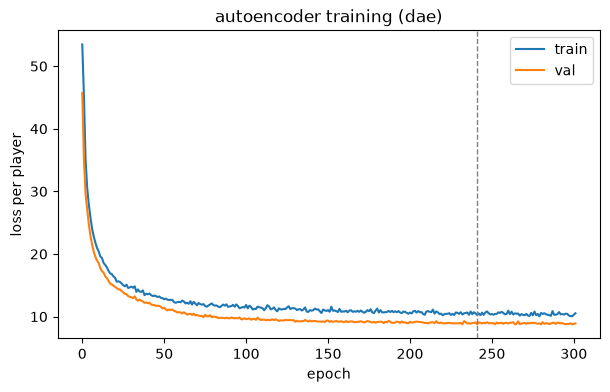

Autoencoder


player,team,league,autoencoder_score
str,str,str,f32
"""Hamari Traoré""","""Paris FC""","""FRA-Ligue 1""",0.276643
"""Yuri Berchiche""","""Athletic Club""","""ESP-La Liga""",0.259731
"""Hauke Wahl""","""St. Pauli""","""GER-Bundesliga""",0.259697
"""Alessandro Buongiorno""","""Napoli""","""ITA-Serie A""",0.241194
"""Youri Regeer""","""Ajax""","""NED-Eredivisie""",0.236677
"""Caleb Okoli""","""Leicester City""","""ENG-EFL Championship""",0.232448
"""Álex Valle""","""Como""","""ITA-Serie A""",0.227789
"""Kristijan Jakić""","""Augsburg""","""GER-Bundesliga""",0.227478
"""Sebastian Walukiewicz""","""Sassuolo""","""ITA-Serie A""",0.227381


In [13]:
# Autoencoder embedding (denoising AE or VAE): learns a compressed nonlinear
# embedding of X_scaled, then ranks players by distance to the target in that
# latent space. Fiddle with AE_CONFIG and rerun this cell; the comparison
# cells below pick the model up automatically.
import torch
import torch.nn as nn

AE_CONFIG = {
    "model": "dae",          # "dae" = denoising autoencoder, "vae" = variational
    "latent_dim": 16,        # embedding size used for similarity
    "hidden_dims": [64],     # encoder layer widths (decoder mirrors them)
    "noise_std": 0.30,       # gaussian noise added to inputs during training
    "mask_prob": 0.15,       # chance of zeroing each feature (corruption, SCARF-style)
    "beta": 1.0,             # KL weight, vae only (<1 favors reconstruction)
    "epochs": 600,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "val_frac": 0.15,        # players held out for early stopping
    "patience": 60,          # stop after this many epochs without val improvement
    "seed": 42,
    "metric": "euclidean",   # "euclidean" or "cosine" in latent space
}


class AutoEncoder(nn.Module):
    def __init__(self, n_features, cfg):
        super().__init__()
        self.variational = cfg["model"] == "vae"
        dims = [n_features, *cfg["hidden_dims"]]
        enc = []
        for a, b in zip(dims, dims[1:]):
            enc += [nn.Linear(a, b), nn.SiLU()]
        self.encoder = nn.Sequential(*enc)
        self.latent_head = nn.Linear(dims[-1], cfg["latent_dim"] * (2 if self.variational else 1))
        dec_dims = [cfg["latent_dim"], *reversed(cfg["hidden_dims"])]
        dec = []
        for a, b in zip(dec_dims, dec_dims[1:]):
            dec += [nn.Linear(a, b), nn.SiLU()]
        dec.append(nn.Linear(dec_dims[-1], n_features))
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.latent_head(self.encoder(x))
        if self.variational:
            mu, logvar = h.chunk(2, dim=-1)
            return mu, logvar
        return h, None

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu
        if self.variational and self.training:
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decoder(z), mu, logvar


def ae_loss(recon, target, mu, logvar, cfg):
    # summed over features / latent dims, averaged over the batch
    rec = ((recon - target) ** 2).sum(dim=1).mean()
    if logvar is None:
        return rec, float(rec.detach()), 0.0
    kl = (-0.5 * (1 + logvar - mu**2 - logvar.exp())).sum(dim=1).mean()
    return rec + cfg["beta"] * kl, float(rec.detach()), float(kl.detach())


def train_autoencoder(X, cfg):
    torch.manual_seed(cfg["seed"])
    rng = np.random.default_rng(cfg["seed"])
    perm = rng.permutation(len(X))
    n_val = max(1, int(len(X) * cfg["val_frac"]))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    X_t = torch.tensor(X, dtype=torch.float32)
    X_train, X_val = X_t[train_idx], X_t[val_idx]

    model = AutoEncoder(X.shape[1], cfg)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    def corrupt(x):
        x = x + torch.randn_like(x) * cfg["noise_std"]
        return x * (torch.rand_like(x) > cfg["mask_prob"])

    history = {"train": [], "val": [], "val_rec": [], "val_kl": []}
    best = {"loss": float("inf"), "state": None, "epoch": -1}
    for epoch in range(cfg["epochs"]):
        model.train()
        order = torch.randperm(len(X_train))
        epoch_loss = 0.0
        for start in range(0, len(order), cfg["batch_size"]):
            batch = X_train[order[start:start + cfg["batch_size"]]]
            recon, mu, logvar = model(corrupt(batch))
            loss, _, _ = ae_loss(recon, batch, mu, logvar, cfg)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += float(loss) * len(batch)
        history["train"].append(epoch_loss / len(X_train))

        model.eval()
        with torch.no_grad():
            recon, mu, logvar = model(X_val)  # validate on clean inputs
            val_loss, val_rec, val_kl = ae_loss(recon, X_val, mu, logvar, cfg)
        history["val"].append(float(val_loss))
        history["val_rec"].append(val_rec)
        history["val_kl"].append(val_kl)

        if float(val_loss) < best["loss"] - 1e-4:
            best.update(loss=float(val_loss), epoch=epoch,
                        state={k: v.clone() for k, v in model.state_dict().items()})
        elif epoch - best["epoch"] >= cfg["patience"]:
            break

    model.load_state_dict(best["state"])
    model.eval()
    with torch.no_grad():
        emb = model.encode(X_t)[0].numpy()
    return model, emb, history, best


ae_model, ae_emb, ae_history, ae_best = train_autoencoder(X_scaled, AE_CONFIG)
msg = (f"{AE_CONFIG['model']}: stopped after {len(ae_history['train'])} epochs, "
       f"best val loss {ae_best['loss']:.3f} at epoch {ae_best['epoch'] + 1}")
if AE_CONFIG["model"] == "vae":
    e = ae_best["epoch"]
    msg += f" (recon {ae_history['val_rec'][e]:.3f}, kl {ae_history['val_kl'][e]:.3f})"
print(msg)

plt.figure(figsize=(7, 4))
plt.plot(ae_history["train"], label="train")
plt.plot(ae_history["val"], label="val")
plt.axvline(ae_best["epoch"], color="gray", ls="--", lw=1)
plt.xlabel("epoch")
plt.ylabel("loss per player")
plt.legend()
plt.title(f"autoencoder training ({AE_CONFIG['model']})")
plt.show()

if AE_CONFIG["metric"] == "cosine":
    ae_scores = cosine_similarity(ae_emb, ae_emb[idx:idx + 1]).ravel().astype(float)
else:
    ae_scores = 1.0 / (1.0 + np.linalg.norm(ae_emb - ae_emb[idx], axis=1))
ae_scores[idx] = -np.inf
scores_by_model["Autoencoder"] = ae_scores
model_names = list(scores_by_model)  # so the comparison cells below include it

print("Autoencoder")
display(top_table(ae_scores, "autoencoder_score"))

Top similar players by model


rank,SIDClustering,KNN,Cosine,MutualReachability,Spearman
i64,str,str,str,str,str
1,"""Ian Maatsen""","""Kodai Sano""","""Jordy Bos""","""Jeremy Ngakia""","""Jordy Bos"""
2,"""Jordy Bos""","""Jordy Bos""","""Kodai Sano""","""Kodai Sano""","""Callum Brittain"""
3,"""Sergiño Dest""","""Malo Gusto""","""Ian Maatsen""","""Rasmus Kristensen""","""Kodai Sano"""
4,"""Jesus Vazquez""","""Mats Wieffer""","""Callum Brittain""","""Nadir Zortea""","""Valentín Barco"""
5,"""Diego Moreira""","""Nadir Zortea""","""Nadir Zortea""","""Jordy Bos""","""Mauro Júnior"""
6,"""Anthony Caci""","""Ian Maatsen""","""Jeremy Ngakia""","""Malo Gusto""","""Oliver Braude"""
7,"""Julian Ryerson""","""Jeremy Ngakia""","""Rasmus Kristensen""","""Mats Wieffer""","""Rasmus Kristensen"""
8,"""Conor Bradley""","""Rasmus Kristensen""","""Malo Gusto""","""Tommaso Barbieri""","""Jonathan Clauss"""
9,"""Achraf Hakimi""","""Tommaso Barbieri""","""Femi Seriki""","""Callum Brittain""","""Óscar Mingueza"""


Consensus (Reciprocal Rank Fusion across models)


player,team,league,rrf_score,SIDClustering_rank,KNN_rank,Cosine_rank,MutualReachability_rank,Spearman_rank
str,str,str,f64,i64,i64,i64,i64,i64
"""Jordy Bos""","""Feyenoord""","""NED-Eredivisie""",0.08043,2,2,1,5,1
"""Nadir Zortea""","""Bologna""","""ITA-Serie A""",0.073251,16,5,5,4,13
"""Rasmus Kristensen""","""Eint Frankfurt""","""GER-Bundesliga""",0.072334,24,8,7,3,7
"""Ian Maatsen""","""Aston Villa""","""ENG-Premier League""",0.071945,1,6,3,34,12
"""Kodai Sano""","""NEC Nijmegen""","""NED-Eredivisie""",0.071771,78,1,2,2,3
"""Sergiño Dest""","""PSV Eindhoven""","""NED-Eredivisie""",0.067162,3,25,15,24,10
"""Callum Brittain""","""Middlesbrough""","""ENG-EFL Championship""",0.066182,117,10,4,9,2
"""Malo Gusto""","""Chelsea""","""ENG-Premier League""",0.065975,51,3,8,6,29
"""Jeremy Ngakia""","""Watford""","""ENG-EFL Championship""",0.065075,118,7,6,1,17


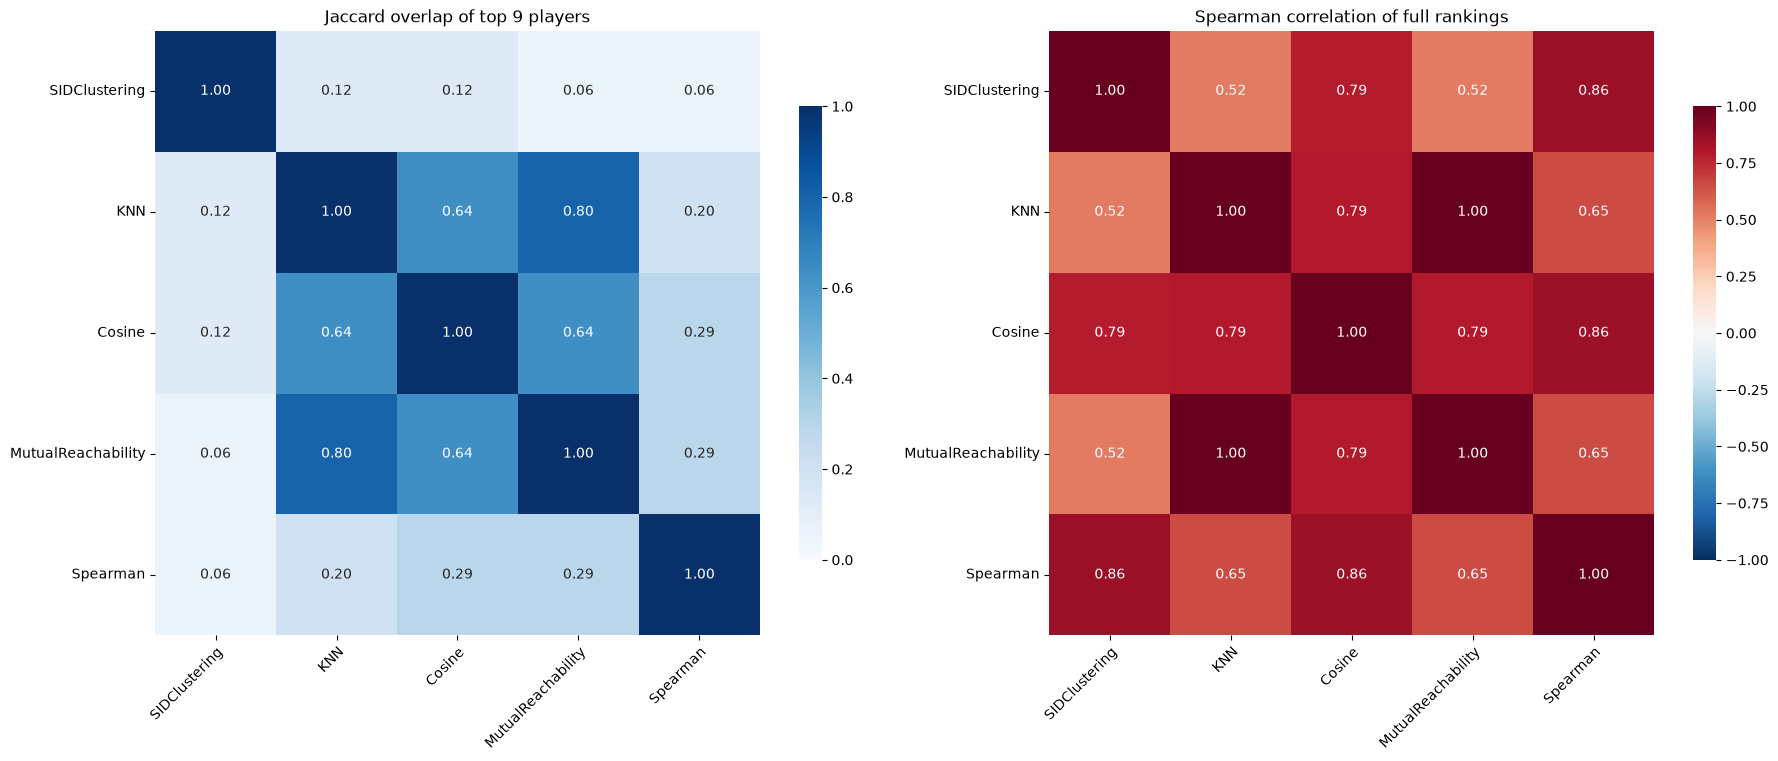

In [10]:
side_by_side = {"rank": list(range(1, top_n + 1))}
top_sets = {}
for name, scores in scores_by_model.items():
    order = np.argsort(scores)[::-1][:top_n]
    players = [all_player["player"][int(i)] for i in order]
    side_by_side[name] = players
    top_sets[name] = set(players)

print("Top similar players by model")
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=80, tbl_width_chars=160):
    display(pl.DataFrame(side_by_side))

k_rrf = 60
ranks_by_model = {}
rrf_scores = np.zeros(n_samples)
for name, scores in scores_by_model.items():
    order = np.argsort(scores)[::-1]
    ranks = np.empty(n_samples)
    ranks[order] = np.arange(1, n_samples + 1)
    ranks_by_model[name] = ranks
    rrf_scores += 1.0 / (k_rrf + ranks)
rrf_scores[idx] = -np.inf

rrf_order = np.argsort(rrf_scores)[::-1][:top_n]
consensus = all_player[rrf_order].select("player", "team", "league").with_columns([
    pl.Series("rrf_score", rrf_scores[rrf_order]),
    *[
        pl.Series(f"{name}_rank", ranks_by_model[name][rrf_order].astype(int))
        for name in model_names
    ],
])

print("Consensus (Reciprocal Rank Fusion across models)")
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=80, tbl_width_chars=160):
    display(consensus)

n_models = len(model_names)
jaccard = np.zeros((n_models, n_models))
spearman = np.zeros((n_models, n_models))
mask = np.isfinite(np.column_stack([scores_by_model[n] for n in model_names])).all(axis=1)

for i, a in enumerate(model_names):
    for j, b in enumerate(model_names):
        union = top_sets[a] | top_sets[b]
        jaccard[i, j] = (len(top_sets[a] & top_sets[b]) / len(union)) if union else 0.0
        spearman[i, j] = spearmanr(scores_by_model[a][mask], scores_by_model[b][mask]).correlation

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), layout="constrained")
heatmap_kw = dict(
    annot=True,
    fmt=".2f",
    xticklabels=model_names,
    yticklabels=model_names,
    square=True,
    cbar_kws={"shrink": 0.75},
)
sb.heatmap(jaccard, cmap="Blues", vmin=0, vmax=1, ax=axes[0], **heatmap_kw)
axes[0].set_title(f"Jaccard overlap of top {top_n} players")
sb.heatmap(spearman, cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[1], **heatmap_kw)
axes[1].set_title("Spearman correlation of full rankings")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.show()